In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from scipy import integrate

In [3]:
mx = 192
mt = 1000
n = 40

In [4]:
#x = np.linspace(0, 1, m2)

t_min = 20.0
t_max = 100.0
tau = 0.1
y_space = np.linspace(t_min+tau/2, t_max+tau/2, mt)
#t_4_Ef = np.arange(t_min + tau/2, t_max + tau/2, tau)
#x = np.linspace(t_min+tau/2, t_max+tau/2, m2)
#x = np.linspace(0, x_range, mx)

x_min = 1
x_max = 3.2
dx = .02
#x = np.arange(x_min, x_max + dx/2, dx)
x_space = np.linspace(x_min, x_max + dx/2, mx)

In [5]:
np.shape(y_space)

(1000,)

In [6]:
np.shape(x_space)

(192,)

In [7]:
import scipy.io as sio
import os

#cwd = os.getcwd()
#os.chdir(cwd)
path = '/home/saumya/NeuralN/deepxsede/spyder tries'
os.environ['PATH'] += ':'+path


mat = sio.loadmat('data_4_training_Ef_1000.mat')    #loading data sets with prob >= 0.99 and not noisy
V_load = mat['V_train']
Ef_load = mat['Ef_train']

In [8]:
V = V_load[:n,:]
Ef = Ef_load[:n,:]

In [9]:
print(np.shape(V))
print(np.shape(V[1,:]))
print(np.shape(Ef))
print(np.shape(Ef[1,:]))

(40, 192)
(192,)
(40, 1000)
(1000,)


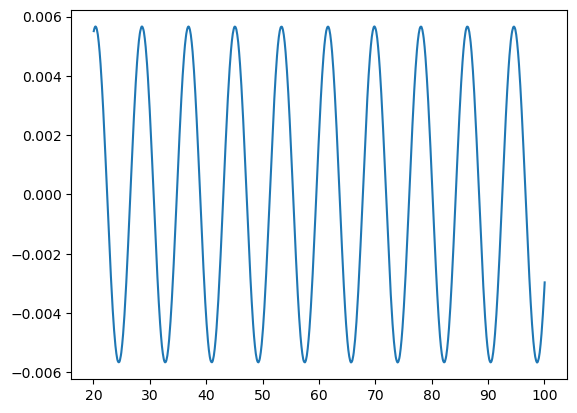

In [10]:
plt.plot(y_space, Ef[1, :])

In [11]:
U_in = np.zeros((mx,n))
U = np.zeros((mx,mt,n))

for ni in range(n):
    x_values = V[ni, :]
    U_in[:,ni] = x_values
    for tt in range(mt):
        U[:,tt,ni] = x_values

In [12]:
#def integrate_data(m1=m1, m2=m2, n=n, x=x, U=V, S=Ef):
#    us = np.zeros((m2*n, m1))
#    xs = np.zeros((m2*n, 1))
#    ss = np.zeros((m2*n, 1))
#    for i in range(n):
#        for j in range(m2):
#            us[i*m2+j, :] = V[i, :]
#            xs[i*m2+j, :] = x[j]
#            ss[i*m2+j, :] = Ef[i, j]
#    return us, xs, ss

def integrate_dataset(mx=mx, mt=mt, n=n, x=x_space, U_in=U_in, U=V, S=Ef):
    us = np.zeros((mx*mt*n, mx))
    xs = np.zeros((mx*mt*n, 2))
    ss = np.zeros((mx*mt*n, 1))
    count = 0
    for i in range(n):
        for j in range(mx):
            for jj in range(mt):
                us[count,:] = U_in[:,i]
                xs[count] = [x_space[j],y_space[jj]]
                ss[count] = Ef[i, jj]
                count = count+1
                
    return us, xs, ss

In [13]:
us,xs,ss = integrate_dataset()
print(us.shape, xs.shape, ss.shape)

(7680000, 192) (7680000, 2) (7680000, 1)


In [14]:
def batch_dataset(batch_size, mx=mx, mt=mt, n=n, x=x_space, U=V, S=Ef, ratio=0.8):
    us, xs, ss = integrate_dataset(mx=mx, mt=mt, n=n, x=x, U_in=U_in, U=V, S=Ef)
    
    train_size = int(len(us)*ratio)
    
    us_train = us[:train_size]
    xs_train = xs[:train_size]
    ss_train = ss[:train_size]
    
    us_test = us[train_size:]
    xs_test = xs[train_size:]
    ss_test = ss[train_size:]
    
    us_train = torch.tensor(us_train, dtype= torch.float32)
    xs_train = torch.tensor(xs_train, dtype= torch.float32)
    ss_train = torch.tensor(ss_train, dtype= torch.float32)
    train_dataset = torch.utils.data.TensorDataset(us_train,xs_train,ss_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    us_test = torch.tensor(us_test, dtype= torch.float32)
    xs_test = torch.tensor(xs_test, dtype= torch.float32)
    ss_test = torch.tensor(ss_test, dtype= torch.float32)
    test_dataset = torch.utils.data.TensorDataset(us_test,xs_test,ss_test)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    
    
    return train_dataloader, test_dataloader

In [15]:
train_data, test_data = batch_dataset(batch_size=32, ratio=0.9)

In [16]:
#for u_batch, x_batch, s_batch in train_data:
#    print(u_batch, x_batch, s_batch)

In [17]:
import torch.nn as nn

class DeepONet(nn.Module):
    def __init__(self, neurons=40, in1 = mx, in2= 2, output_neurons =20):
        super(DeepONet, self).__init__()
        self.neurons = neurons
        self.duble_neurons = 2*neurons
        self.in1 = in1
        self.in2 = in2
        self.output_neurons = output_neurons
        self.branch = self.branch_network()
        self.trunk = self.trunk_network()
        
    def branch_network(self):
        branch = nn.Sequential(
            nn.Linear(self.in1,self.duble_neurons),
            nn.ReLU(),
            nn.Linear(self.duble_neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return branch
        
    def trunk_network(self):
        trunk=nn.Sequential(
            nn.Linear(self.in2,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return trunk
        
    def forward(self, x1, x2):
        x1 = self.branch(x1)
        x2 = self.trunk(x2)
        x = torch.einsum("bi, bi->b", x1,x2)
        x = torch.unsqueeze(x,1)
        return x

In [18]:
model = DeepONet(neurons=40, in1 = mx, in2= 2, output_neurons =20)

In [19]:
def loss(y_pred, y):
    return torch.mean((y_pred - y)**2)

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [21]:
import torch.nn as nn
import torch.optim as optim

train_looses = []

def closure():
    optimizer.zero_grad()
    l_total = 0
    
    for u_, x_, s_ in train_data:
        model.train()
        y_pred = model(u_, x_)
        l = loss(y_pred, s_)
        l_total += l.item()
        l.backward()
    
    l_total = l_total/ len(train_data)
    train_looses.append(l_total)
    
    return l_total

epochs = 30

for i in range(epochs):
    optimizer.step(closure)
    
    if i%10 == 0:
        print("Epoch", i, " / ", epochs, "loss ", train_looses[-1])


Epoch 0  /  30 loss  4.635946786346259
Epoch 10  /  30 loss  0.6425193291184389
Epoch 20  /  30 loss  0.09199045308756952


In [22]:
torch.save(model,'epoch30.pth')

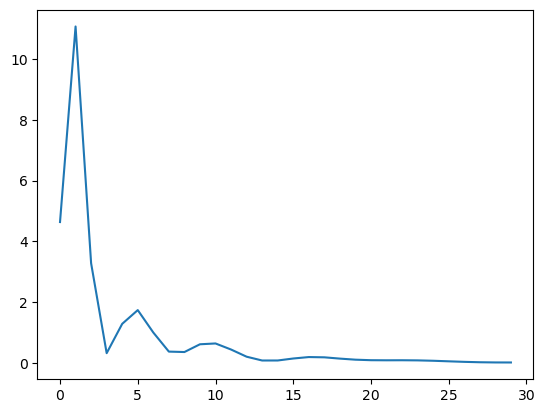

In [24]:
plt.plot(train_looses)

In [25]:
#model1 = DeepONet()
#model1.load_state_dict(torch.load('epoch30.pth'))
model1 = torch.load('epoch30.pth')
model1.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=192, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

(192, 1000)
(192, 1000)


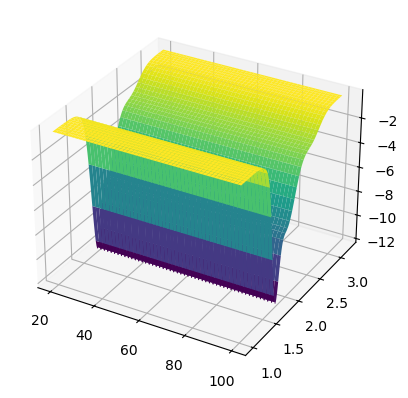

In [26]:
X, Y = np.meshgrid(y_space, x_space)
print(X.shape)
print(Y.shape)
fig = plt.figure()
ax = fig.add_subplot(111, projection ='3d')
ax.plot_surface(X, Y, U[:,:,10], cmap='viridis')

In [27]:
u_t = V[20,:]
s_t = Ef[20,:]

In [28]:
model.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=192, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [29]:
x_train = torch.tensor(x_space, dtype=torch.float32)

In [30]:
fV = V_load[100:100+n,:]
fEf = Ef_load[100:100+n,:]

In [31]:
FF_in = np.zeros((mx,n))
FF = np.zeros((mx,mt,n))

for ni in range(n):
    x_values = fV[ni, :]
    FF_in[:,ni] = x_values
    for tt in range(mt):
        FF[:,tt,ni] = x_values

#for nn in range(n):
#    x_values = one_function(x_gen)
#    UU_in[:,nn] = x_values
#    for tt in range(mt):
#        UU[:,tt,nn] = x_values



In [32]:
# change the number here if want to see more
target_result = 13
################################################
F_gen = FF_in[:,target_result]

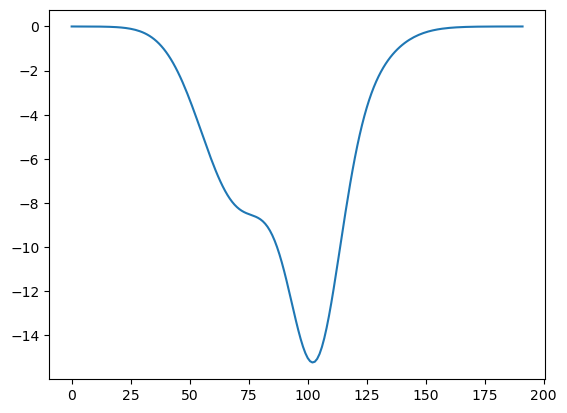

In [33]:
plt.plot(F_gen)

In [34]:
FF_gen = torch.tensor(F_gen, dtype=torch.float32).unsqueeze(0)

In [35]:
combinations = []

for i in range(len(x_space)):
    for j in range(len(y_space)):
        combinations.append((x_space[i], y_space[j]))
        
combinations = np.array(combinations)
print(combinations.shape)
print(combinations)

(192000, 2)
[[  1.          20.05      ]
 [  1.          20.13008008]
 [  1.          20.21016016]
 ...
 [  3.21        99.88983984]
 [  3.21        99.96991992]
 [  3.21       100.05      ]]


In [36]:
xt_train = torch.tensor(combinations, dtype=torch.float32)

In [37]:
FF_gen.shape, xt_train.shape

(torch.Size([1, 192]), torch.Size([192000, 2]))

In [38]:
model.eval()
p = model(FF_gen, xt_train)

In [39]:
print(p.T)

tensor([[0.0567, 0.0570, 0.0574,  ..., 0.4145, 0.4148, 0.4152]],
       grad_fn=<PermuteBackward0>)


In [40]:
p=p.detach().numpy()

In [41]:
p.shape

(192000, 1)

In [42]:
p_reshaped = p.reshape(mx, mt)

In [43]:
p_reshaped.shape

(192, 1000)

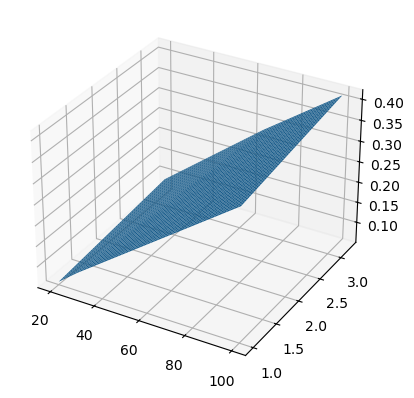

In [44]:
Xs, Ys = np.meshgrid(y_space,x_space)
fig = plt.figure()
ax = fig.add_subplot(111, projection ='3d')
ax.plot_surface(Xs, Ys, p_reshaped)

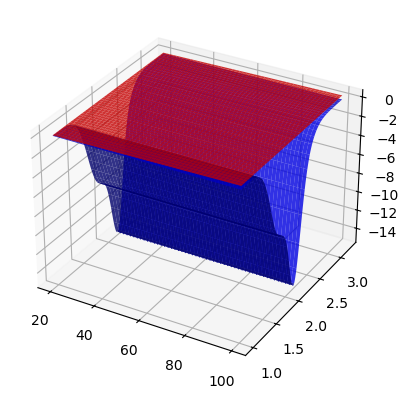

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111, projection ='3d')

ax.plot_surface(Xs, Ys, FF[:,:,target_result], alpha=0.8, color = 'b')

ax.plot_surface(Xs, Ys, p_reshaped, alpha=0.8, color = 'r')